# Tutorial 1.2 - Stochastically Solving a Spatially Homogeneous Bimolecular System #

## Introduction ##
In this tutorial, we will examine a stochastic treatment of the bimolecular chemical system from Tutorial 1.1. To do so, we will use **`jLM`**. Within the **`jLM`** package, we will need to import several libraries. The first is **`jLM.CME`** which is the main engine for stochastically simulating spatially homogeneous systems. The second, **`jLM.units`**, is a utility library to convert between scientific units. Finally, we will import the **`jLM.CMEPostProcessing`** library which contains functionality used for analysis of species trajectories and other post-processing commands.

## Set the Working Directory and Import Necessary Packages ##

In [1]:
# Import necessary packages #
import os, sys

# Define function to find desired working directory #
def _find_tutorial_dir(notebook_filename):
    """Locate this notebook's directory by searching upward from CWD."""
    start = os.path.abspath(os.getcwd())
    search = start
    for _ in range(8):
        if os.path.isfile(os.path.join(search, notebook_filename)):
            return search
        for subdir in ['LM/CME/Tutorial01_BimolecularReactions',
                       'CME/Tutorial01_BimolecularReactions',
                       'Tutorial01_BimolecularReactions']:
            candidate = os.path.abspath(os.path.join(search, subdir))
            if os.path.isfile(os.path.join(candidate, notebook_filename)):
                return candidate
        search = os.path.dirname(search)
    return None

# Define desired working directory #
_here = _find_tutorial_dir('Tut1.2-CMEBimol.ipynb')
if _here is None:
    raise RuntimeError(
        "Cannot locate Tutorial01_BimolecularReactions/. "
        "Please ensure the repository structure is intact."
    )

# Set working directory #
os.chdir(_here)
print(f"Working directory set to:\n{_here}")

Working directory set to:
/data/GitHub_Repos/SummerSchool_2026/LM/CME/Tutorial01_BimolecularReactions


In [22]:
# Import standard python libraries #
import os
import numpy as np
import matplotlib.pyplot as plt

# Import jLM libraries #
import jLM.CME as CME
import jLM.units as units
import jLM.CMEPostProcessing as PostProcessing

# Enable plotting inline in the Jupyter notebook #
%matplotlib inline

# Add Utils/ to path and import custom plotting module #
sys.path.insert(0, os.path.abspath('../Utils'))
import custom_plot as plot

## Define the CME Simulation Object ##

We begin by creating a **`CMESimulation`** Python object that we call `sim`. This object will hold all information necessary to run the stochastic simulation.

In [11]:
# Create our CME simulation object
sim = CME.CMESimulation(name='Bimolecular Reaction')

As with Tutorial 1.1, we will begin by defining our chemical system. We start by setting the volume of our system and defining Avogadro's number. 

In [12]:
# Define chemical system #
# Volume #
V  = 1.0e-15    # L
# Avogadro's number #
NA = 6.022e23   # Molecules/mole

Next we define all chemical species included in the simulation. We begin by specifying the names of the chemical species (these can be chosen as arbitrary strings of characters).  Then we add these species to the simulation using the **`defineSpecies()`** function, which can be called on python list objects (as is done below), or multiple times on individual python string objects.


In [13]:
# Define our chemical species list #
species = ['A', 'B', 'C']
# Add the chemical species to the CME simulation object #
sim.defineSpecies(species)

Next, we add the initial particle counts to the simulation using the **`addParticles()`** function. This function syntax is similar to the **`defineSpecies()`** function, but requires that the species already be added to the simulation object, the user to define the species, and the user to define the number of molecules of the designated species as an python integer object.

In [14]:
# Set our initial species counts #
sim.addParticles(species='A', count=50)
sim.addParticles(species='B', count=50)
sim.addParticles(species='C', count=0)

Now that we have added all chemical species and their initial abundances, we add reactions to the simulation. To do this, we use the **`addReaction()`** function that is a member of the **`CMESimulation`** object. In the cell below, We add a bimolecular association reaction with species "A" and "B" as the reactants and species "C" as the product. We then add a unimolecular dissociation reaction with species "C" as the reactant and "A" and "B" as the products. When more than one reactant or product is involved in a reaction, the list of reactant names should be passed as a python tuple object, as can be seen in the `reactant` variable of the association reaction. 

Before adding the reactions to our simulation object, we must also define our reaction rates and the `fold` variable. The `fold` variable is not necessary to run the simulation but allows us to change the magnitudes of rate constants easily in the future. After defining the concentration-based rate constants, we will need to convert these to molecule-based rate constants, as this is the input format that Lattice Microbes requires.


In [15]:
# Define fold variable for future analyses #
fold = 1
# Define rate constants for each reaction in the system #
# Forward reaction (A + B -> C) #
kf_Concentration = fold * 1.07e6 # /Molar/s
# Reverse reaction (C -> A + B) #
kr_Concentration = fold * 0.351  # /s

# Convert from concentration-based rate constants to particle-based rate constants #
# Convert from 1.07e6 /M/s to /counts/s - Second-order reaction conversion #
kf = kf_Concentration/(NA*V)  
# Convert from 0.351 /s to /s - First-order reaction conversion #
kr = kr_Concentration

# Add reactions to the simulation
sim.addReaction(reactant=('A','B'), product='C', rate=kf)
sim.addReaction(reactant='C', product=('A','B'), rate=kr)

Next, we define the simulation execution parameters. We will run the simulation run for 30 seconds of biological time and can set this parameter in the `sim` object by using the **`setSimulationTime()`** function, feeding the function a float or integer python object. Next we choose to write the state of the system (particle counts) every 30 microseconds. This means that every 30 microseconds of simulation time, the simulation queries the state of the system and then writes this state as a data point for the simulation output. Using these specific parameters creates an output trajectory for each species with 1,000,000 time points. To set the simulation write interval, we use the **`setWriteInterval`** function. This function requires its input to be passed in seconds, so we can either convert manually between microseconds and seconds, or we can use the **`jLM`** helper function **`units`**.

Next, we define the number of replicate simulations we would like to run of our defined chemical system. Then we name the simulation output file and save output file name to the simulation object.

In [ ]:
# Define simulation-specific parameters #
# Define amount of biological time to run simulation #
tstart =  0.0   # s
tend   = 30.0   # s
# If tstart = 0, add the desired ending time to the simulation object #
sim.setSimulationTime(tend)
# Define the write interval in the simulation object to specify how frequently to write the state of the simulation to the output data #
write_time = 30e-6   # s
# Add write interval to the simulation object #
sim.setWriteInterval(write_time)
# Optional: use units jLM function #
# sim.setWriteInterval(units.microseconds(30))
# Define the number of replicates to perform of the simulation #
reps = 10
# Define the output filename for the simulation #
filename = "./T1.2-bimol.lm"
# Remove any existing file with the same name as the output #
os.system("rm -rf %s"%(filename))
# Save the simulation #
sim.save(filename)

Finally, before performing the actual simulations, we can optionally print the simulation object information to make sure we have entered everything correctly.

In [ ]:
# Print simulation parameters to the notebook for checking before final sim.run #
print(f"Name:           {sim.name}")
print(f"Species:        {sim.species_id}")
print(f"Initial counts: {sim.initial_counts}")
print(f"Parameters:     {sim.parameters}")
print("Reactions:")
for reactant, product, rate in sim.reactions:
    print(f"  {reactant} -> {product}  (rate={rate})")

Name:           Bimolecular Reaction
Species:        ['A', 'B', 'C']
Initial counts: {'A': 50, 'B': 50, 'C': 0}
Parameters:     {'maxTime': '30.0', 'writeInterval': '3e-05'}
Reactions:
  ('A', 'B') -> C  (rate=0.001776818332779807)
  C -> ('A', 'B')  (rate=0.351)


## Run the CME Simulation ##

Next we run the simulation using the **`run`** function within the simulation object. This function requires the `filename` and `replicates` parameters, which we have defined above. It also requires the `method` parameter, which allows the user to specify the type of stochastic simulation algorithm used by the solver. Lattice Microbes supports several different solvers for CME simulations; here we use the most common algorithm called the Gillespie algorithm (aka the Stochastic Simulation Algorithm). You can learn more about the types of stochastic simulation algorithms that exist from a review article by Gillespie [review paper](https://www.annualreviews.org/content/journals/10.1146/annurev.physchem.58.032806.104637) and/or the following [wikipedia page](https://en.wikipedia.org/wiki/Gillespie_algorithm). The results of the simulations are saved to the output file specified as a ".lm" file.

In [18]:
# Perform the stochastic well-mixed chemical kinetic simulation on our defined simulation object #
sim.run(filename=filename, method="lm::cme::GillespieDSolver", replicates=reps)

  0%|          | 0/10 [00:00<?, ?it/s]

2026-06-15 15:59:57) Info: Using 32 processor(s) and 1 CUDA device(s) per process.
2026-06-15 15:59:57) Info: Assigning 1.00 processor(s) and 1.00 CUDA device(s) per replicate.
2026-06-15 15:59:57) Info: Data output thread running.
2026-06-15 15:59:57) Info: Seeding xorwow rng with top word 1 and bottom word 929192532
2026-06-15 15:59:58) Info: Data output thread finished.
2026-06-15 15:59:58) Info: Simulation file closed.


 10%|#         | 1/10 [00:00<00:03,  2.42it/s]

2026-06-15 15:59:58) Info: Using 32 processor(s) and 1 CUDA device(s) per process.
2026-06-15 15:59:58) Info: Assigning 1.00 processor(s) and 1.00 CUDA device(s) per replicate.
2026-06-15 15:59:58) Info: Data output thread running.
2026-06-15 15:59:58) Info: Seeding xorwow rng with top word 2 and bottom word 78560975
2026-06-15 15:59:58) Info: Data output thread finished.
2026-06-15 15:59:58) Info: Simulation file closed.


 20%|##        | 2/10 [00:00<00:01,  4.13it/s]

...

 80%|########  | 8/10 [00:01<00:00,  8.14it/s]

2026-06-15 15:59:58) Info: Using 32 processor(s) and 1 CUDA device(s) per process.
2026-06-15 15:59:58) Info: Assigning 1.00 processor(s) and 1.00 CUDA device(s) per replicate.
2026-06-15 15:59:58) Info: Data output thread running.
2026-06-15 15:59:58) Info: Seeding xorwow rng with top word 9 and bottom word 891664868
2026-06-15 15:59:58) Info: Data output thread finished.
2026-06-15 15:59:59) Info: Simulation file closed.


 90%|######### | 9/10 [00:01<00:00,  8.21it/s]

2026-06-15 15:59:59) Info: Using 32 processor(s) and 1 CUDA device(s) per process.
2026-06-15 15:59:59) Info: Assigning 1.00 processor(s) and 1.00 CUDA device(s) per replicate.
2026-06-15 15:59:59) Info: Data output thread running.
2026-06-15 15:59:59) Info: Seeding xorwow rng with top word 10 and bottom word 10842528
2026-06-15 15:59:59) Info: Data output thread finished.
2026-06-15 15:59:59) Info: Simulation file closed.


100%|##########| 10/10 [00:01<00:00,  6.85it/s]


## Analysis of Simulation Data ##

Congratulations! You have run your first LM simulation! 

Now, after performing simulations, we obtain species trajectories for each chemical species in the simulation. These can then be used for any arbitrary number or types of downstream analyses. **`jLM`** has its post-processing library called **`jLM.CMEPostProcessing`**, which we have already loaded into the python session. We will begin our post-simulation analyses by showcasing **`jLM.CMEPostProcessing`** and then will describe how to perform custom analyses on the output files.

Post-processing with **`jLM.CMEPostProcessing`** generally begins by opening the simulation output file. This is accomplished by passing the filename to the function **`openLMFile()`**. This function performs some background error checking to make sure the file is generated by LM.

The function **`plotTrace`** within **`jLM.CMEPostProcessing`** will plot a list of species (user-specified) from a specific simulation replicate. Here, we only need to plot species A or B because they will be identical due to the structure of our chemical system.

After running the post-processing commands, we close the LM File. It is very important that if you open an LM file with the function **`openLMFile`** that it be closed at the end of your post-processing with **`closeLMFile`**. This function takes the filehandle that is returned by **`openLMFile`** as an argument. Also, note that once this function is called, any function that takes the filehandle as an argument will fail to work as the handle is now stale. This function is usually called last in a post-processing script.



To start, we will plot the trajectories of one replicate (**`rep`**), which we have randomly chosen to be 5.

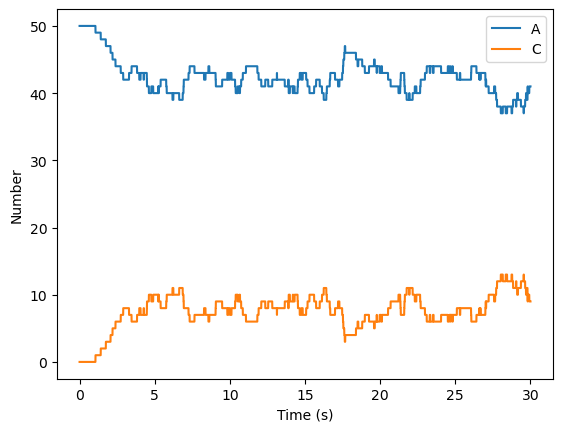

In [19]:
# Define the file handle for the LM output file generated by simulations #
fileHandle = PostProcessing.openLMFile(filename)
# Define which replicate we want to plot #
rep = 5
# Perform the plotting #
PostProcessing.plotTrace(fileHandle, species=['A','C'], replicate=rep)
# Close the LM output file #
PostProcessing.closeLMFile(fileHandle)

If we want to see information on the average behavior of each species across replicates, we can use the **`plotAvgVar`** function to display the mean value of each species across time (first output plot) and the variance of each species across time (second output plot).

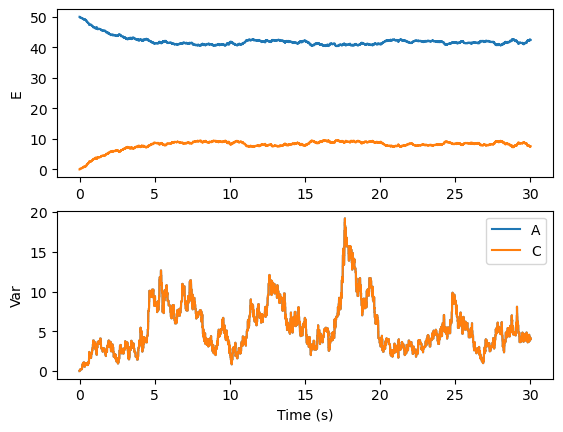

In [20]:
# Define the file handle for the LM output file generated by simulations #
fileHandle = PostProcessing.openLMFile(filename)
# Perform the plotting #
PostProcessing.plotAvgVar(fileHandle, species=['A','C'])
# Close the LM output file #
PostProcessing.closeLMFile(fileHandle)

Although it may be simple to use, the standard post-processing library has its limitations:
1. First and foremost, it can only read in LM files generated during the simulation while whole-cell models are not strictly LM file types.
2. Second, the built-in ploting functions can only plot line plots, and we may want more to use plotting methods, including histograms, heatmaps, etc. 
3. Third, these functions are generally slower than the normal Matplotlib functions.

As such, we will show a more general method to handle the trajectories. This will involve reading in the LM file to a 3D numpy array with the following dimensions: time, species, replicates. We will do this using the **`h5py`** library. This gives us the freedom to plot and analyze the output data arbitrairly by slicing this 3D array.

In [24]:
# Define the file handle for the LM output file generated by simulations #
fileHandle = PostProcessing.openLMFile(filename)
# Use PostProcessing to get the simulation timesteps #
timestep = PostProcessing.getTimesteps(fileHandle) 

# Initialize 3D numpy array full of zeros with proper dimensions to store trajectory data #
trajectory_temp = np.zeros((len(timestep), len(sim.particleMap), reps)) 

# Use custome plotting function in the /Utils/ directory to read the trajectories for each species and each replicate into the 3D numpy array #
trajectories = plot.get_sim_data(trajectory_temp, reps, filename)
# Check that the species trajectories were loaded in correctly #
print('The size of the 3D trajectories is {0} with dimensions time, species, and replicates.'.format(np.shape(trajectory_temp)))

The size of the 3D trajectories is (1000001, 3, 10) with dimensions time, species, and replicates.


Next, we will ensure that the output plot directory has been named and created. This should have been completed in Tutorial 1.1 for the deterministic treatment of the bimolecular chemical system.

In [25]:
# Create folder to store plotted figures
fig_dir = './Plots/'
# Ensure the output plot directory exists if not already created #
if not os.path.exists(fig_dir):
    os.mkdir(fig_dir)

Next, we will generate a plot that contains the species trajectories of a single replicate. We will also use the randomly selected replicate (number 5) we used with the **`CMEPostProcessing`** module.

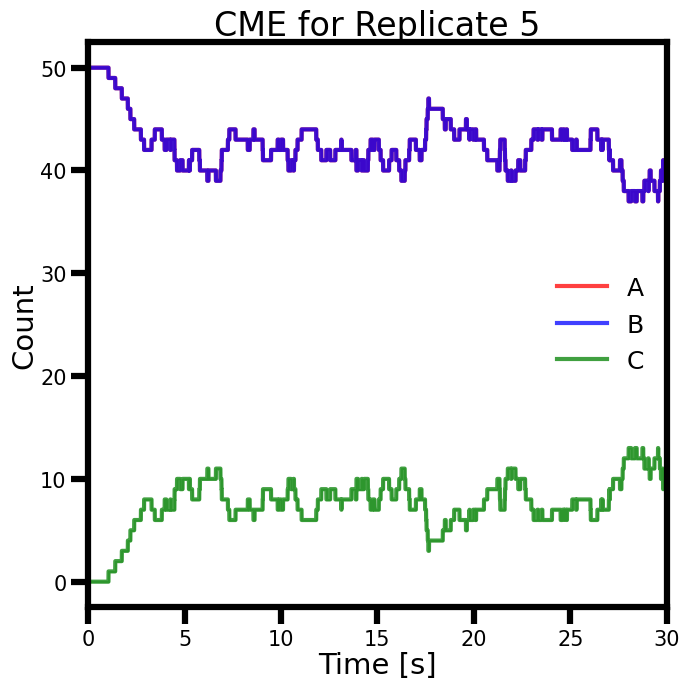

In [27]:
# Define a name for the figure #
fig_name = 'Bimolecular_CME_trajectories_rep{0}_{1}foldrates'.format(rep, fold)
# Define figure length and height dimensions (inches) #
fig_size = [7, 7]
# Define the variable time as the entries for the time axis of the 3D numpy array #
time = np.linspace(tstart, tend, trajectories.shape[0])
# Extract out data from the trajectories object for each species #
data_list=[trajectories[:,0:1,rep-1], trajectories[:,1:2,rep-1], trajectories[:,2:3,rep-1]]
# Define plot species names as "legends" #
legends = ['A','B','C']
# Define plot colors for species #
colors = ['red', 'blue', 'green']
# Define x-axis label #
xlabel='Time [s]'
# Define y-axis label #
ylabel='Count'
# Define plot title #
title=f'CME for Replicate {rep}'
# Run the plotting function #
plot.plot_time_ranges(fig_dir, fig_name, fig_size,
               time, data_list, legends, colors, xlabel, ylabel, title,
               plot_avg=True, plot_range=False, xlimit=[tstart, tend],
               title_set=True, fonts_sizes=[21, 21, 24, 18],
               extension='.png', tick_setting=[12, 4.5, 15, 'out'], line_widths = [3,4.5],
               legend_pos='best')

Finally, we will plot the average value for species "A" across all timepoints and replicates of our simulation.

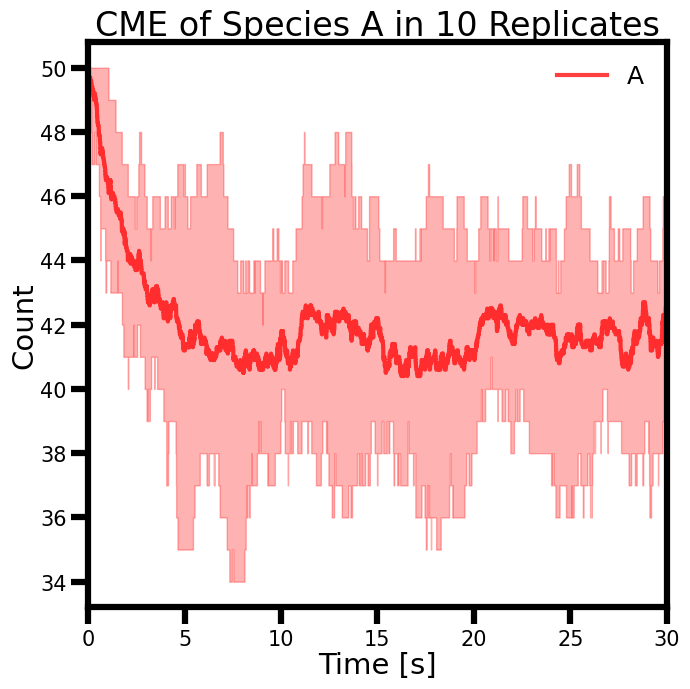

In [35]:
# Define species of interest #
species = 'A'
# Define a name for the figure #
fig_name = 'Bimolecular_CME_{0}_{1}replicates_{2}foldrates'.format(species, reps, fold)
# Define figure length and height dimensions (inches) #
fig_size = [7, 7] 
# Define the variable time as the entries for the time axis of the 3D numpy array #
time = np.linspace(tstart, tend, trajectories.shape[0])
# Extract all trajectories for species "A" from the trajectories object #
data_list=[trajectories[:,0,:]]
# Define species names to variable named "legends" #
legends = ['A']
# Define species trajectory colors #
colors = ['red']
# Define x-axis label #
xlabel='Time [s]'
# Define y-axis label #
ylabel='Count'
# Define plot title #
title=f'CME of Species {species} in {reps} Replicates'
# Define the upper and lower percentile bounds for the species to be shaded in a lighter color #
# This is only taken into effect if plot_range = True #
# [0,100] is the min and max values of the species at each time point #
percentile = [0,100]
# Perform plotting function #
plot.plot_time_ranges(fig_dir, fig_name, fig_size,
               time, data_list, legends, colors, xlabel, ylabel, title,
               percentile, plot_avg=True, plot_range=True, xlimit=[tstart, tend],
               title_set=True, fonts_sizes=[21, 21, 24, 18],
               extension='.png', tick_setting=[12.0, 4.5, 15, 'out'], line_widths = [3,4.5],
               legend_pos='best')